<a href="https://colab.research.google.com/github/ss48/opencv/blob/master/Face_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
!rm -f /content/face_detection_yunet.onnx
!rm -f /content/face_recognition_sface.onnx

!wget -O /content/face_detection_yunet.onnx \
  "https://huggingface.co/opencv/opencv_zoo/resolve/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx?download=true"

!wget -O /content/face_recognition_sface.onnx \
  "https://huggingface.co/opencv/opencv_zoo/resolve/main/models/face_recognition_sface/face_recognition_sface_2021dec.onnx?download=true"

!ls -lh /content/face_detection_yunet.onnx /content/face_recognition_sface.onnx


--2026-03-15 19:56:04--  https://huggingface.co/opencv/opencv_zoo/resolve/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx?download=true
Resolving huggingface.co (huggingface.co)... 3.169.137.111, 3.169.137.119, 3.169.137.19, ...
Connecting to huggingface.co (huggingface.co)|3.169.137.111|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/6835c1a834109f3463ba2273/d3fbb6028fc86125755b70f69f428ebbf39fbb01cfa5df3e3dbe1563148ae349?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27face_detection_yunet_2023mar.onnx%3B+filename%3D%22face_detection_yunet_2023mar.onnx%22%3B&Expires=1773608165&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiRXBvY2hUaW1lIjoxNzczNjA4MTY1fX0sIlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjgzNWMxYTgzNDEwOWYzNDYzYmEyMjczL2QzZmJiNjAyOGZjODYxMjU3NTViNzBmNjlmNDI4ZWJiZjM5ZmJiMDFjZmE1ZGYzZTNkYmUxNTYzMTQ4YWUzNDlcXD9yZXNwb25zZS1jb250Z

In [26]:
import argparse

# Re-initialize the parser to avoid conflicts on re-execution
parser = argparse.ArgumentParser()
parser.add_argument('--face_detection_model', '-fd', type=str,
                    default='/content/face_detection_yunet.onnx')

parser.add_argument('--face_recognition_model', '-fr', type=str,
                    default='/content/face_recognition_sface.onnx')

_StoreAction(option_strings=['--face_recognition_model', '-fr'], dest='face_recognition_model', nargs=None, const=None, default='/content/face_recognition_sface.onnx', type=<class 'str'>, choices=None, required=False, help=None, metavar=None)

Face 0, top-left coordinates: (397, 123), box width: 251, box height 339, score: 0.95


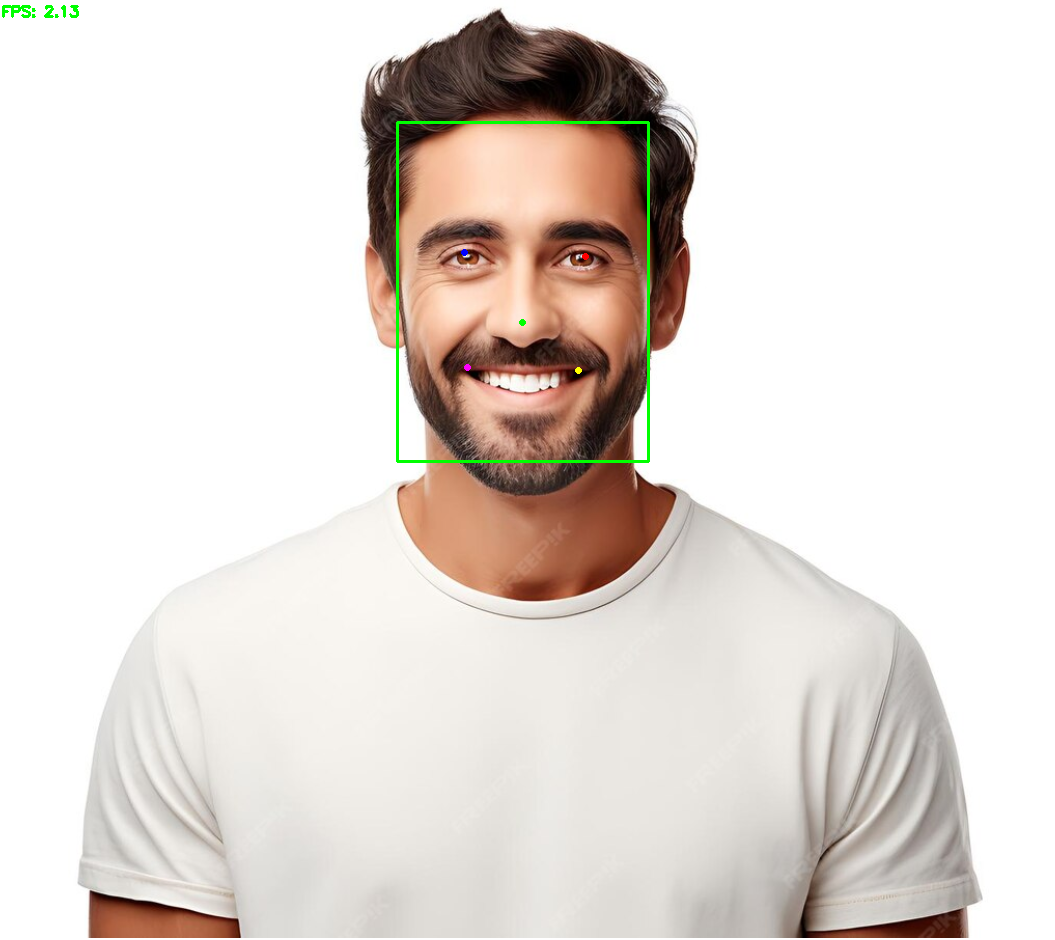

In [34]:
import argparse
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow

def str2bool(v):
    if isinstance(v, bool):
        return v
    if v.lower() in ['on', 'yes', 'true', 'y', 't']:
        return True
    elif v.lower() in ['off', 'no', 'false', 'n', 'f']:
        return False
    else:
        raise NotImplementedError

parser = argparse.ArgumentParser()

# Set a real default image path in /content
parser.add_argument('--image1', '-i1', type=str, default='/content/man1.png')
parser.add_argument('--image2', '-i2', type=str, default=None)
parser.add_argument('--video', '-v', type=str, default=None)
parser.add_argument('--scale', '-sc', type=float, default=1.0)

# Use the model filenames you downloaded successfully
parser.add_argument('--face_detection_model', '-fd', type=str,
                    default='/content/face_detection_yunet.onnx')
parser.add_argument('--face_recognition_model', '-fr', type=str,
                    default='/content/face_recognition_sface.onnx')

parser.add_argument('--score_threshold', type=float, default=0.9)
parser.add_argument('--nms_threshold', type=float, default=0.3)
parser.add_argument('--top_k', type=int, default=5000)
parser.add_argument('--save', '-s', type=str2bool, default=False)

# Important for Colab
args = parser.parse_args([])
args.image1 = "/content/man1.png"
def visualize(image, faces, fps, thickness=2):
    if faces[1] is not None:
        for idx, face in enumerate(faces[1]):
            print(
                'Face {}, top-left coordinates: ({:.0f}, {:.0f}), '
                'box width: {:.0f}, box height {:.0f}, score: {:.2f}'.format(
                    idx, face[0], face[1], face[2], face[3], face[-1]
                )
            )

            coords = face[:-1].astype(np.int32)
            cv.rectangle(image, (coords[0], coords[1]),
                         (coords[0] + coords[2], coords[1] + coords[3]),
                         (0, 255, 0), thickness)
            cv.circle(image, (coords[4], coords[5]), 2, (255, 0, 0), thickness)
            cv.circle(image, (coords[6], coords[7]), 2, (0, 0, 255), thickness)
            cv.circle(image, (coords[8], coords[9]), 2, (0, 255, 0), thickness)
            cv.circle(image, (coords[10], coords[11]), 2, (255, 0, 255), thickness)
            cv.circle(image, (coords[12], coords[13]), 2, (0, 255, 255), thickness)

    cv.putText(image, 'FPS: {:.2f}'.format(fps), (1, 16),
               cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

if __name__ == '__main__':
    detector = cv.FaceDetectorYN.create(
        args.face_detection_model,
        "",
        (320, 320),
        args.score_threshold,
        args.nms_threshold,
        args.top_k
    )

    tm = cv.TickMeter()

    # Image mode only
    if args.image1 is not None:
        img1 = cv.imread(args.image1)
        if img1 is None:
            raise ValueError(f"Could not read image: {args.image1}")

        img1Width = int(img1.shape[1] * args.scale)
        img1Height = int(img1.shape[0] * args.scale)
        img1 = cv.resize(img1, (img1Width, img1Height))

        tm.start()
        detector.setInputSize((img1Width, img1Height))
        faces1 = detector.detect(img1)
        tm.stop()

        assert faces1[1] is not None, f'Cannot find a face in {args.image1}'

        visualize(img1, faces1, tm.getFPS())

        if args.save:
            print('Results saved to result.jpg')
            cv.imwrite('result.jpg', img1)

        cv2_imshow(img1)

        if args.image2 is not None:
            img2 = cv.imread(args.image2)
            if img2 is None:
                raise ValueError(f"Could not read image: {args.image2}")

            tm.reset()
            tm.start()
            detector.setInputSize((img2.shape[1], img2.shape[0]))
            faces2 = detector.detect(img2)
            tm.stop()

            assert faces2[1] is not None, f'Cannot find a face in {args.image2}'
            visualize(img2, faces2, tm.getFPS())
            cv2_imshow(img2)

            recognizer = cv.FaceRecognizerSF.create(
                args.face_recognition_model, ""
            )

            face1_align = recognizer.alignCrop(img1, faces1[1][0])
            face2_align = recognizer.alignCrop(img2, faces2[1][0])

            face1_feature = recognizer.feature(face1_align)
            face2_feature = recognizer.feature(face2_align)

            cosine_similarity_threshold = 0.363
            l2_similarity_threshold = 1.128

            cosine_score = recognizer.match(
                face1_feature, face2_feature, cv.FaceRecognizerSF_FR_COSINE
            )
            l2_score = recognizer.match(
                face1_feature, face2_feature, cv.FaceRecognizerSF_FR_NORM_L2
            )

            msg = 'different identities'
            if cosine_score >= cosine_similarity_threshold:
                msg = 'the same identity'
            print(
                f'They have {msg}. Cosine Similarity: {cosine_score}, '
                f'threshold: {cosine_similarity_threshold}'
            )

            msg = 'different identities'
            if l2_score <= l2_similarity_threshold:
                msg = 'the same identity'
            print(
                f'They have {msg}. NormL2 Distance: {l2_score}, '
                f'threshold: {l2_similarity_threshold}'
            )
